In [1]:
import numpy as np
import tensorflow as tf
import tensorflow.keras.layers as layers
import matplotlib.pyplot as plt
import math

def global_normalized_cross_correlation_loss():
    def ncc(y_true, y_pred):
        """Computes the normalized cross-correlation (NCC) loss.

        Parameters
        ----------
        y_true : tf.Tensor
            The static image to which the moving image is aligned.
        y_pred : tf.Tensor
            The moving image, the same shape as the static image.

        Returns
        -------
        loss : tf.Tensor, shape ()
            Normalized cross-correlation loss between the static and the
            moving images, averaged over the batch. Range is [-1.0, 1.0].
            The best value is -1 (perfect match) and the worst is 1.

        References
        ----------
        .. [1] `Wikipedia entry for the Cross-correlation
               <https://en.wikipedia.org/wiki/Cross-correlation>`_

        """
        ndim = tf.keras.backend.ndim(y_true)-2

        # shape (N, 1, 1, C)
        y_true_mean = tf.reduce_mean(y_true, axis=range(1, ndim+1),
                                     keepdims=True)
        y_pred_mean = tf.reduce_mean(y_pred, axis=range(1, ndim+1),
                                     keepdims=True)
        plt.ylabel('Loss')

        y_true_hat = tf.math.l2_normalize(y_true-y_true_mean,
                                          axis=range(1, ndim+1))

        y_pred_hat = tf.math.l2_normalize(y_pred-y_pred_mean,
                                          axis=range(1, ndim+1))

        return -tf.reduce_mean(tf.reduce_sum(y_true_hat * y_pred_hat,
                                             axis=range(1, ndim+1)))
    return ncc


def local_normalized_cross_correlation_loss(window=(6, 6, 6), eps=1e-5):
    """
    Code borrowed from https://github.com/voxelmorph/voxelmorph/blob/legacy/src/losses.py#L28
    Paper: https://openaccess.thecvf.com/content_cvpr_2018/papers/Balakrishnan_An_Unsupervised_Learning_CVPR_2018_paper.pdf
    """
    def ncc(I, J, window=window):
        # get dimension of volume
        # assumes I, J are sized [batch_size, *vol_shape, nb_feats]
        # ndims = len(I.get_shape().as_list()) - 2
        ndims = tf.keras.backend.ndim(I)-2
        assert ndims in [1, 2, 3], "volumes should be 1 to 3 dimensions. found: %d" % ndims

        # set window size
        if window is None:
            window = [9] * ndims

        # get convolution function
        conv_fn = getattr(tf.nn, 'conv%dd' % ndims)

        # compute CC squares
        I2 = I*I
        J2 = J*J
        IJ = I*J

        # compute filters
        sum_filt = tf.ones([*window, 1, 1])
        strides = [1] * (ndims + 2)
        padding = 'SAME'

        # compute local sums via convolution
        I_sum = conv_fn(I, sum_filt, strides, padding)
        J_sum = conv_fn(J, sum_filt, strides, padding)
        I2_sum = conv_fn(I2, sum_filt, strides, padding)
        J2_sum = conv_fn(J2, sum_filt, strides, padding)
        IJ_sum = conv_fn(IJ, sum_filt, strides, padding)

        # compute cross correlation
        win_size = np.prod(window)
        u_I = I_sum/win_size
        u_J = J_sum/win_size

        cross = IJ_sum - u_J*I_sum - u_I*J_sum + u_I*u_J*win_size
        I_var = I2_sum - 2 * u_I * I_sum + u_I*u_I*win_size
        J_var = J2_sum - 2 * u_J * J_sum + u_J*u_J*win_size

        cc = cross*cross / (I_var*J_var + eps)

        # return negative cc.
        return -tf.reduce_mean(cc)
    return ncc

# vein. Portal veins are well enhanced and some enhancement of the hepatic veins is also seen on the portal venous phase. T
def gradient_loss(norm=2):
    """
    Code borrowed from https://github.com/voxelmorph/voxelmorph/blob/legacy/pytorch/losses.py#L13
    Paper: https://openaccess.thecvf.com/content_cvpr_2018/papers/Balakrishnan_An_Unsupervised_Learning_CVPR_2018_paper.pdf
    """
    def grad_loss(_, phi):
        di = tf.abs(phi[:, 1:, :, :, :] - phi[:, :-1, :, :, :])
        dj = tf.abs(phi[:, :, 1:, :, :] - phi[:, :, :-1, :, :])
        dk = tf.abs(phi[:, :, :, 1:, :] - phi[:, :, :, :-1, :])

        loss = tf.reduce_mean(di) + tf.reduce_mean(dj) + tf.reduce_mean(dk)
        if norm == 2:
            loss = tf.reduce_mean(di**2) + tf.reduce_mean(dj**2) + tf.reduce_mean(dk**2)    
        return loss
    return grad_loss

def regular_grid_3d(depth, height, width):
    """Returns a 3-D regular grid.

    Parameters
    ----------
    depth : int
        The desired depth of the grid.
    height : int
        The desired height of the grid.
    width : int
        The desired width of the grid.
    Returns
    -------
    grid : tf.Tensor, shape (D, H, W, 3)
        A 3-D regular grid, values normalized to [-1.0, 1.0]
        range.

    Notes
    -----
    Sampling using the regular grid is an identity transformation, i.e.,
    it results in the same input and output images.

    References
    ----------
    .. [1] `NumPy, "numpy.meshgrid"
        <https://numpy.org/doc/stable/reference/generated/numpy.meshgrid.html>`_
    .. [2] `NumPy, "numpy.indices"
        <https://numpy.org/doc/stable/reference/generated/numpy.indices.html>`_

    """
    i = tf.linspace(-1.0, 1.0, depth)
    j = tf.linspace(-1.0, 1.0, height)
    k = tf.linspace(-1.0, 1.0, width)

    I, J, K = tf.meshgrid(i, j, k, indexing='ij')

    grid = tf.stack([I, J, K], axis=-1)
    return grid


def grid_sample_3d(moving, grid, name=None):
    """Given a moving image and a sampling grid as input, computes the
    transformed image by sampling the moving image at locations given by
    the grid.

    Parameters
    ----------
    moving : tf.Tensor, shape (N, D, H, W, C)
        The moving image.
    grid : tf.Tensor, shape (N, D, H, W, C)
        A tensor of sampling points (x, y, z). The x, y and z values should be
        normalized to [-1.0, 1.0] range.
    name : str
        Name for the operation.

    Returns
    -------
    moved : tf.Tensor, shape (N, D, H, W, C)
        The transformed image.

    Notes
    -----
    Let M be the moving image of shape (H, W, C), T be the transformed
    image of the same shape and G be the 2D sampling grid of shape
    (H, W, 2). The value of T at a location (x, y) is T[y, x, :] =
    M[y', x', :] where [x', y'] = G[y, x, :].

    Further, [x', y'] = [x + dx, y + dy] where [dx, dy] are the
    displacements outputted by the CNN. When dx and dy are 0, the
    sampling grid G is a regular grid and the transformed image is the
    same as the moving image.

    Since the sampling point (x + dx, y + dy) can be non-integral, the
    value M[y', x'] is calculated using bi-linear interpolation.

    References
    ----------
    .. [1] `Jaderberg, Max, Karen Simonyan, and Andrew Zisserman. "Spatial
        transformer networks." Advances in neural information processing
        systems. 2015. <https://arxiv.org/abs/1506.02025>`_
    .. [2] `TensorFlow implementation of spatial transformer networks.
        <https://github.com/tensorflow/models/tree/master/research/transformer>`_
    .. [3] `Spatial Transformer Networks by Kushagra Bhatnagar
        <https://link.medium.com/0b2OrmqVO5>`_
        
    """
    nb, nd, nh, nw, nc = tf.shape(moving)
    
    i = grid[..., 0]  # shape (N, D, H, W)
    j = grid[..., 1]
    k = grid[..., 2]
    i = tf.cast(i, 'float32')
    j = tf.cast(j, 'float32')
    k = tf.cast(k, 'float32')

    # Scale i, j and k from [-1.0, 1.0] to [0, D], [0, H] and [0, W] respectively.
    i = (i + 1.0) * 0.5 * tf.cast(nd-1, 'float32')
    j = (j + 1.0) * 0.5 * tf.cast(nh-1, 'float32')
    k = (k + 1.0) * 0.5 * tf.cast(nw-1, 'float32')

    i_max = tf.cast(nd - 1, 'int32')
    j_max = tf.cast(nh - 1, 'int32')
    k_max = tf.cast(nw - 1, 'int32')
    zero = tf.constant(0, 'int32')

    # The value at (i, j, k) is a weighted average of the values at the
    # eight nearest integer locations: (i0, j0, k0), (i0, j0, k1), (i0, j1, k0),
    # (i0, j1, k1), (i1, j0, k0), (i1, j0, k1), (i1, j1, k0) and (i1, j1, k1)
    # where i0 = floor(i), i1 = ceil(i).
    i0 = tf.cast(tf.floor(i), 'int32')
    i1 = i0 + 1
    j0 = tf.cast(tf.floor(j), 'int32')
    j1 = j0 + 1
    k0 = tf.cast(tf.floor(k), 'int32')
    k1 = k0 + 1

    # Make sure indices are within the boundaries of the image.
    i0 = tf.clip_by_value(i0, zero, i_max)
    i1 = tf.clip_by_value(i1, zero, i_max)
    j0 = tf.clip_by_value(j0, zero, j_max)
    j1 = tf.clip_by_value(j1, zero, j_max)
    k0 = tf.clip_by_value(k0, zero, k_max)
    k1 = tf.clip_by_value(k1, zero, k_max)

    # Collect indices of the four corners.
    b = tf.ones_like(i0) * tf.reshape(tf.range(nb), [nb, 1, 1, 1])
    idx_a = tf.stack([b, i1, j0, k0], axis=-1)  # all front-top-left corners
    idx_b = tf.stack([b, i1, j1, k0], axis=-1)  # all front-bottom-left corners
    idx_c = tf.stack([b, i1, j0, k1], axis=-1)  # all front-top-right corners
    idx_d = tf.stack([b, i1, j1, k1], axis=-1)  # all front-bottom-right corners
    idx_e = tf.stack([b, i0, j0, k0], axis=-1)  # all back-top-left corners
    idx_f = tf.stack([b, i0, j1, k0], axis=-1)  # all back-bottom-left corners
    idx_g = tf.stack([b, i0, j0, k1], axis=-1)  # all back-top-right corners
    idx_h = tf.stack([b, i0, j1, k1], axis=-1)  # all back-bottom-right corners
    # shape (N, D, H, W, 3)

    # Collect values at the corners.
    moving_a = tf.gather_nd(moving, idx_a)  # all front-top-left values
    moving_b = tf.gather_nd(moving, idx_b)  # all front-bottom-left values
    moving_c = tf.gather_nd(moving, idx_c)  # all front-top-right values
    moving_d = tf.gather_nd(moving, idx_d)  # all front-bottom-right values
    moving_e = tf.gather_nd(moving, idx_e)  # all back-top-left values
    moving_f = tf.gather_nd(moving, idx_f)  # all back-bottom-left values
    moving_g = tf.gather_nd(moving, idx_g)  # all back-top-right values
    moving_h = tf.gather_nd(moving, idx_h)  # all back-bottom-right values
    # shape (N, D, H, W, C)

    i0_f = tf.cast(i0, 'float32')
    i1_f = tf.cast(i1, 'float32')
    j0_f = tf.cast(j0, 'float32')
    j1_f = tf.cast(j1, 'float32')
    k0_f = tf.cast(k0, 'float32')
    k1_f = tf.cast(k1, 'float32')

    # Calculate the weights.
    wa = tf.expand_dims((i - i0_f) * (j1_f - j) * (k1_f - k), axis=-1)
    wb = tf.expand_dims((i - i0_f) * (j - j0_f) * (k1_f - k), axis=-1)
    wc = tf.expand_dims((i - i0_f) * (j1_f - j) * (k - k0_f), axis=-1)
    wd = tf.expand_dims((i - i0_f) * (j - j0_f) * (k - k0_f), axis=-1)
    we = tf.expand_dims((i1_f - i) * (j1_f - j) * (k1_f - k), axis=-1)
    wf = tf.expand_dims((i1_f - i) * (j - j0_f) * (k1_f - k), axis=-1)
    wg = tf.expand_dims((i1_f - i) * (j1_f - j) * (k - k0_f), axis=-1)
    wh = tf.expand_dims((i1_f - i) * (j - j0_f) * (k - k0_f), axis=-1)

    # Calculate the weighted sum.
    moved = tf.add_n([wa * moving_a, wb * moving_b, wc * moving_c,
                      wd * moving_d, we * moving_e, wf * moving_f,
                      wg * moving_g, wh * moving_h], name=name)
    return moved

class VoxelMorph1(object):
    def __init__(self, input_shape=(32, 32, 1), optimizer='adam', loss=None,
                 metrics=None, loss_weights=None):
        in_channels = 1
        out_channels = 3
        input_shape = input_shape + (in_channels,)

        moving = layers.Input(shape=input_shape, name='moving')
        static = layers.Input(shape=input_shape, name='static')
        
        
        x_in = layers.concatenate([static, moving], axis=-1)

        # encoder
        x1 = layers.Conv3D(16, kernel_size=3, strides=2, padding='same',
                           kernel_initializer='he_normal')(x_in)
        x1 = layers.LeakyReLU(alpha=0.2)(x1)  # 16

        x2 = layers.Conv3D(32, kernel_size=3, strides=2, padding='same',
                           kernel_initializer='he_normal')(x1)
        x2 = layers.LeakyReLU(alpha=0.2)(x2)  # 8

        x3 = layers.Conv3D(32, kernel_size=3, strides=2, padding='same',
                           kernel_initializer='he_normal')(x2)
        x3 = layers.LeakyReLU(alpha=0.2)(x3)  # 4

        x4 = layers.Conv3D(32, kernel_size=3, strides=2, padding='same',
                           kernel_initializer='he_normal')(x3)
        x4 = layers.LeakyReLU(alpha=0.2)(x4)  # 2

        # decoder [32, 32, 32, 32, 8, 8]
        x = layers.Conv3D(32, kernel_size=3, strides=1, padding='same',
                          kernel_initializer='he_normal')(x4)
        x = layers.LeakyReLU(alpha=0.2)(x)
        x = layers.UpSampling3D(size=2)(x)  # 4
        x = layers.concatenate([x, x3], axis=-1)  # 4

        x = layers.Conv3D(32, kernel_size=3, strides=1, padding='same',
                          kernel_initializer='he_normal')(x)
        x = layers.LeakyReLU(alpha=0.2)(x)
        x = layers.UpSampling3D(size=2)(x)  # 8
        x = layers.concatenate([x, x2], axis=-1)  # 8

        x = layers.Conv3D(32, kernel_size=3, strides=1, padding='same',
                          kernel_initializer='he_normal')(x)
        x = layers.LeakyReLU(alpha=0.2)(x)
        x = layers.UpSampling3D(size=2)(x)  # 16
        x = layers.concatenate([x, x1], axis=-1)  # 16

        x = layers.Conv3D(32, kernel_size=3, strides=1, padding='same',
                          kernel_initializer='he_normal')(x)
        x = layers.LeakyReLU(alpha=0.2)(x)

        x = layers.Conv3D(8, kernel_size=3, strides=1, padding='same',
                          kernel_initializer='he_normal')(x)
        x = layers.LeakyReLU(alpha=0.2)(x)  # 16

        x = layers.UpSampling3D(size=2)(x)  # 32
        x = layers.concatenate([x, x_in], axis=-1)
        x = layers.Conv3D(8, kernel_size=3, strides=1, padding='same',
                          kernel_initializer='he_normal')(x)
        feature_maps = x
        x = layers.LeakyReLU(alpha=0.2)(x)  # 32

        kernel_initializer = tf.keras.initializers.RandomNormal(mean=0.0,
                                                                stddev=1e-5)
        deformation = layers.Conv3D(out_channels, kernel_size=3, strides=1,
                                    padding='same',
                                    kernel_initializer=kernel_initializer,
                                    name='deformation')(x)

        # print(deformation.shape)
        nb, nd, nh, nw, nc = tf.shape(deformation)

        # Regular grid.
        grid = regular_grid_3d(nd, nh, nw)  # shape (D, H, W, 2)
        # print(grid.shape)
        grid = tf.expand_dims(grid, axis=0)  # shape (1, D, H, W, 2)
        multiples = tf.stack([nb, 1, 1, 1, 1])
        grid = tf.tile(grid, multiples)

        # Compute the new sampling grid.moved
        grid_new = grid + deformation
        grid_new = tf.clip_by_value(grid_new, -1, 1)
        # print(grid_new.shape)

        # Sample the moving image using the new sampling grid.
        moved = grid_sample_3d(moving, grid_new, name='moved')
        
        model = tf.keras.Model(inputs={'moving': moving, 'static': static},
                               outputs={'moved': moved, 'deformation': deformation}, name='voxelmorph1')
        model.compile(optimizer=optimizer, loss=loss, metrics=metrics,
                      loss_weights=loss_weights)
        
        self.model = model

    def compile(self, optimizer='adam', loss=None, metrics=None,
                loss_weights=None):
        self.model.compile(optimizer=optimizer, loss=loss, metrics=metrics,
                           loss_weights=loss_weights)

    def summary(self):
        return self.model.summary()

    def fit(self, x=None, y=None, batch_size=None, epochs=1, verbose=1,
            callbacks=None, validation_split=0.0, validation_data=None,
            shuffle=True, initial_epoch=0, steps_per_epoch=None,
            validation_steps=None, validation_batch_size=None,
            validation_freq=1, max_queue_size=10, workers=1,
            use_multiprocessing=False):
        return self.model.fit(x=x, y=y, batch_size=batch_size,
                              epochs=epochs, verbose=verbose,
                              callbacks=callbacks,
                              validation_split=validation_split,
                              validation_data=validation_data, shuffle=shuffle,
                              initial_epoch=initial_epoch,
                              steps_per_epoch=steps_per_epoch,
                              validation_steps=validation_steps,
                              validation_batch_size=validation_batch_size,
                              validation_freq=validation_freq,
                              max_queue_size=max_queue_size, workers=workers,
                              use_multiprocessing=use_multiprocessing)

    def evaluate(self, x=None, y=None, batch_size=None, verbose=1,
                 steps=None, callbacks=None, max_queue_size=10, workers=1,
                 use_multiprocessing=False, return_dict=False):
        return self.model.evaluate(x=x, y=y, batch_size=batch_size,
                                   verbose=verbose, steps=steps,
                                   callbacks=callbacks,
                                   max_queue_size=max_queue_size,
                                   workers=workers,
                                   use_multiprocessing=use_multiprocessing,
                                   return_dict=return_dict)

    def predict(self, x, batch_size=None, verbose=0,
                steps=None, callbacks=None, max_queue_size=10, workers=1,
                use_multiprocessing=False):
        return self.model.predict(x=x, batch_size=batch_size,
                                  verbose=verbose, steps=steps,
                                  callbacks=callbacks,
                                  max_queue_size=max_queue_size,
                                  workers=workers,
                                  use_multiprocessing=use_multiprocessing)

    def save_weights(self, filepath, overwrite=True):
        self.model.save_weights(filepath=filepath, overwrite=overwrite, save_format=None)

    def load_weights(self, filepath):
        self.model.load_weights(filepath)
        
class RegistrationDataLoader(tf.keras.utils.Sequence):
    def __init__(self, moving, static, batch_size=8, shuffle=False):
        """Data loader object that fetches and preprocess batches of images 
        for real-time data feeding to the model.

        Currently supports only numpy arrays as input.
    
        Parameters
        ----------
        moving : ndarray, shape (N, ..., C)
            An array of all the moving images. N is the number of images.
        static : ndarray, shape (1, ..., C)
            The static image.

        """
        self.moving = moving
        self.static = static
        self.batch_size = batch_size
        self.shuffle = shuffle

        if self.shuffle:
            np.random.shuffle(self.moving)

    def __len__(self):
        return math.ceil(len(self.moving) / self.batch_size)

    def __getitem__(self, idx):
        moving = self.moving[idx * self.batch_size: (idx+1) * self.batch_size]
        static = np.repeat(self.static, repeats=moving.shape[0], axis=0)

        return {'moving': moving, 'static': static}, static  # input and output

    def on_epoch_end(self):
        if self.shuffle:
            np.random.shuffle(self.moving)

In [2]:
batch_size = 4
epochs = 500
lr = 0.001  # learning rate
lamda = 0.2  # (lambda) regularization parameter
input_shape = (64, 128, 128)

In [3]:
# 0~1 사이로 정규화 
import nibabel as nib
import os 

# filename = "./mix_data/mixed_affine.nii.gz"
# filename2 = "./static_data_exis/7.nii.gz"
filename = "./chaos_train_voxel/affine_exis_mixed.nii.gz"
filename2 = "./chaos_train_voxel/static_exis/30.nii.gz"
# filename3 = "./chaos_train_voxel/gt_resize/24.nii.gz"

data = nib.load(filename).get_fdata()
static = nib.load(filename2).get_fdata()

min_value = np.min(data)
max_value = np.max(data)

data = (data-min_value) / (max_value-min_value)
print(min_value)
print(max_value)

0.0
2360.43701171875


In [4]:
x_train = data[:13, ...][..., None]
x_train = x_train.astype(np.float32) 
x_test = data[13:, ...][..., None]
x_test = x_test.astype(np.float32)
x_sample = data[0:, ...].copy()  # some images to visualize results

static = (static-min_value) / (max_value-min_value)
static = static[None, ..., None]
static = static.astype(np.float32)

print('Train: ', x_train.shape) 
print('Test: ', x_test.shape)
print('Sample: ', x_sample.shape)
print('Static: ', static.shape)

train_loader = RegistrationDataLoader(x_train, static, batch_size=batch_size,
                                      shuffle=True)
test_loader = RegistrationDataLoader(x_test, static, batch_size=batch_size,
                                     shuffle=True)
sample_loader = RegistrationDataLoader(x_sample, static, shuffle=False)

Train:  (13, 64, 128, 128, 1)
Test:  (6, 64, 128, 128, 1)
Sample:  (19, 64, 128, 128)
Static:  (1, 64, 128, 128, 1)


In [3]:
ncc_loss = global_normalized_cross_correlation_loss()
grad_loss = gradient_loss()

# Map model outputs to the loss functions and loss weights
loss_weights = {'moved': 1.0, 'deformation': lamda}
losses = {'moved': ncc_loss, 'deformation': grad_loss}

optimizer = tf.keras.optimizers.Adam(learning_rate=lr)

model = VoxelMorph1(input_shape=input_shape, optimizer=optimizer,
                    loss=losses, loss_weights=loss_weights)

In [6]:
import tensorflow

early_stop = tensorflow.keras.callbacks.EarlyStopping(monitor="val_loss", min_delta=0, patience=200, restore_best_weights=True) 
checkpoint_path = "./check_points/0627_cp.ckpt"
checkpoint_dir = os.path.dirname(checkpoint_path)

cp_callback = tf.keras.callbacks.ModelCheckpoint(filepath=checkpoint_path,
                                   save_weights_only=True,
                                   verbose=1)# Train the model with the new callback

Epoch 1/500
4/4 [==============================] - ETA: 0s - loss: -0.7867 - deformation_loss: 7.1505e-06 - tf_op_layer_moved_loss: -0.7867
Epoch 00001: saving model to ./check_points/0627_cp.ckpt
4/4 [==============================] - 3s 633ms/step - loss: -0.7867 - deformation_loss: 7.1505e-06 - tf_op_layer_moved_loss: -0.7867 - val_loss: -0.7097 - val_deformation_loss: 3.0801e-05 - val_tf_op_layer_moved_loss: -0.7098
Epoch 2/500
4/4 [==============================] - ETA: 0s - loss: -0.7655 - deformation_loss: 1.6355e-05 - tf_op_layer_moved_loss: -0.7655
Epoch 00002: saving model to ./check_points/0627_cp.ckpt
4/4 [==============================] - 1s 299ms/step - loss: -0.7655 - deformation_loss: 1.6355e-05 - tf_op_layer_moved_loss: -0.7655 - val_loss: -0.7704 - val_deformation_loss: 1.5113e-05 - val_tf_op_layer_moved_loss: -0.7704
Epoch 3/500
4/4 [==============================] - ETA: 0s - loss: -0.7825 - deformation_loss: 2.3198e-05 - tf_op_layer_moved_loss: -0.7825
Epoch 00003:

Epoch 21/500
4/4 [==============================] - ETA: 0s - loss: -0.8853 - deformation_loss: 0.0073 - tf_op_layer_moved_loss: -0.8868
Epoch 00021: saving model to ./check_points/0627_cp.ckpt
4/4 [==============================] - 1s 303ms/step - loss: -0.8853 - deformation_loss: 0.0073 - tf_op_layer_moved_loss: -0.8868 - val_loss: -0.8647 - val_deformation_loss: 0.0055 - val_tf_op_layer_moved_loss: -0.8658
Epoch 22/500
4/4 [==============================] - ETA: 0s - loss: -0.8825 - deformation_loss: 0.0069 - tf_op_layer_moved_loss: -0.8839
Epoch 00022: saving model to ./check_points/0627_cp.ckpt
4/4 [==============================] - 1s 317ms/step - loss: -0.8825 - deformation_loss: 0.0069 - tf_op_layer_moved_loss: -0.8839 - val_loss: -0.8863 - val_deformation_loss: 0.0095 - val_tf_op_layer_moved_loss: -0.8882
Epoch 23/500
4/4 [==============================] - ETA: 0s - loss: -0.8928 - deformation_loss: 0.0071 - tf_op_layer_moved_loss: -0.8942
Epoch 00023: saving model to ./check_

Epoch 41/500
4/4 [==============================] - ETA: 0s - loss: -0.9222 - deformation_loss: 0.0048 - tf_op_layer_moved_loss: -0.9232
Epoch 00041: saving model to ./check_points/0627_cp.ckpt
4/4 [==============================] - 1s 357ms/step - loss: -0.9222 - deformation_loss: 0.0048 - tf_op_layer_moved_loss: -0.9232 - val_loss: -0.9220 - val_deformation_loss: 0.0046 - val_tf_op_layer_moved_loss: -0.9230
Epoch 42/500
4/4 [==============================] - ETA: 0s - loss: -0.9343 - deformation_loss: 0.0042 - tf_op_layer_moved_loss: -0.9351
Epoch 00042: saving model to ./check_points/0627_cp.ckpt
4/4 [==============================] - 1s 303ms/step - loss: -0.9343 - deformation_loss: 0.0042 - tf_op_layer_moved_loss: -0.9351 - val_loss: -0.9239 - val_deformation_loss: 0.0044 - val_tf_op_layer_moved_loss: -0.9248
Epoch 43/500
4/4 [==============================] - ETA: 0s - loss: -0.9255 - deformation_loss: 0.0042 - tf_op_layer_moved_loss: -0.9264
Epoch 00043: saving model to ./check_

Epoch 61/500
4/4 [==============================] - ETA: 0s - loss: -0.9380 - deformation_loss: 0.0037 - tf_op_layer_moved_loss: -0.9387
Epoch 00061: saving model to ./check_points/0627_cp.ckpt
4/4 [==============================] - 1s 293ms/step - loss: -0.9380 - deformation_loss: 0.0037 - tf_op_layer_moved_loss: -0.9387 - val_loss: -0.9261 - val_deformation_loss: 0.0041 - val_tf_op_layer_moved_loss: -0.9270
Epoch 62/500
4/4 [==============================] - ETA: 0s - loss: -0.9327 - deformation_loss: 0.0039 - tf_op_layer_moved_loss: -0.9335
Epoch 00062: saving model to ./check_points/0627_cp.ckpt
4/4 [==============================] - 1s 289ms/step - loss: -0.9327 - deformation_loss: 0.0039 - tf_op_layer_moved_loss: -0.9335 - val_loss: -0.9298 - val_deformation_loss: 0.0038 - val_tf_op_layer_moved_loss: -0.9306
Epoch 63/500
4/4 [==============================] - ETA: 0s - loss: -0.9392 - deformation_loss: 0.0038 - tf_op_layer_moved_loss: -0.9400
Epoch 00063: saving model to ./check_

Epoch 81/500
4/4 [==============================] - ETA: 0s - loss: -0.9286 - deformation_loss: 0.0041 - tf_op_layer_moved_loss: -0.9294
Epoch 00081: saving model to ./check_points/0627_cp.ckpt
4/4 [==============================] - 1s 285ms/step - loss: -0.9286 - deformation_loss: 0.0041 - tf_op_layer_moved_loss: -0.9294 - val_loss: -0.9169 - val_deformation_loss: 0.0035 - val_tf_op_layer_moved_loss: -0.9176
Epoch 82/500
4/4 [==============================] - ETA: 0s - loss: -0.9348 - deformation_loss: 0.0041 - tf_op_layer_moved_loss: -0.9356
Epoch 00082: saving model to ./check_points/0627_cp.ckpt
4/4 [==============================] - 1s 345ms/step - loss: -0.9348 - deformation_loss: 0.0041 - tf_op_layer_moved_loss: -0.9356 - val_loss: -0.9313 - val_deformation_loss: 0.0038 - val_tf_op_layer_moved_loss: -0.9320
Epoch 83/500
4/4 [==============================] - ETA: 0s - loss: -0.9391 - deformation_loss: 0.0037 - tf_op_layer_moved_loss: -0.9399
Epoch 00083: saving model to ./check_

...

Epoch 341/500
4/4 [==============================] - ETA: 0s - loss: -0.9393 - deformation_loss: 0.0037 - tf_op_layer_moved_loss: -0.9400
Epoch 00341: saving model to ./check_points/0627_cp.ckpt
4/4 [==============================] - 1s 281ms/step - loss: -0.9393 - deformation_loss: 0.0037 - tf_op_layer_moved_loss: -0.9400 - val_loss: -0.9314 - val_deformation_loss: 0.0035 - val_tf_op_layer_moved_loss: -0.9321
Epoch 342/500
4/4 [==============================] - ETA: 0s - loss: -0.9413 - deformation_loss: 0.0035 - tf_op_layer_moved_loss: -0.9420
Epoch 00342: saving model to ./check_points/0627_cp.ckpt
4/4 [==============================] - 1s 279ms/step - loss: -0.9413 - deformation_loss: 0.0035 - tf_op_layer_moved_loss: -0.9420 - val_loss: -0.9409 - val_deformation_loss: 0.0034 - val_tf_op_layer_moved_loss: -0.9416
Epoch 343/500
4/4 [==============================] - ETA: 0s - loss: -0.9485 - deformation_loss: 0.0035 - tf_op_layer_moved_loss: -0.9492
Epoch 00343: saving model to ./che

Epoch 361/500
4/4 [==============================] - ETA: 0s - loss: -0.9468 - deformation_loss: 0.0032 - tf_op_layer_moved_loss: -0.9475
Epoch 00361: saving model to ./check_points/0627_cp.ckpt
4/4 [==============================] - 1s 293ms/step - loss: -0.9468 - deformation_loss: 0.0032 - tf_op_layer_moved_loss: -0.9475 - val_loss: -0.9325 - val_deformation_loss: 0.0033 - val_tf_op_layer_moved_loss: -0.9332
Epoch 362/500
4/4 [==============================] - ETA: 0s - loss: -0.9444 - deformation_loss: 0.0032 - tf_op_layer_moved_loss: -0.9450
Epoch 00362: saving model to ./check_points/0627_cp.ckpt
4/4 [==============================] - 1s 290ms/step - loss: -0.9444 - deformation_loss: 0.0032 - tf_op_layer_moved_loss: -0.9450 - val_loss: -0.9400 - val_deformation_loss: 0.0029 - val_tf_op_layer_moved_loss: -0.9405
Epoch 363/500
4/4 [==============================] - ETA: 0s - loss: -0.9481 - deformation_loss: 0.0031 - tf_op_layer_moved_loss: -0.9488
Epoch 00363: saving model to ./che

Epoch 381/500
4/4 [==============================] - ETA: 0s - loss: -0.9461 - deformation_loss: 0.0031 - tf_op_layer_moved_loss: -0.9467
Epoch 00381: saving model to ./check_points/0627_cp.ckpt
4/4 [==============================] - 1s 288ms/step - loss: -0.9461 - deformation_loss: 0.0031 - tf_op_layer_moved_loss: -0.9467 - val_loss: -0.9374 - val_deformation_loss: 0.0030 - val_tf_op_layer_moved_loss: -0.9380
Epoch 382/500
4/4 [==============================] - ETA: 0s - loss: -0.9493 - deformation_loss: 0.0030 - tf_op_layer_moved_loss: -0.9499
Epoch 00382: saving model to ./check_points/0627_cp.ckpt
4/4 [==============================] - 1s 355ms/step - loss: -0.9493 - deformation_loss: 0.0030 - tf_op_layer_moved_loss: -0.9499 - val_loss: -0.9395 - val_deformation_loss: 0.0029 - val_tf_op_layer_moved_loss: -0.9401
Epoch 383/500
4/4 [==============================] - ETA: 0s - loss: -0.9461 - deformation_loss: 0.0031 - tf_op_layer_moved_loss: -0.9467
Epoch 00383: saving model to ./che

Epoch 401/500
4/4 [==============================] - ETA: 0s - loss: -0.9443 - deformation_loss: 0.0031 - tf_op_layer_moved_loss: -0.9449
Epoch 00401: saving model to ./check_points/0627_cp.ckpt
4/4 [==============================] - 1s 337ms/step - loss: -0.9443 - deformation_loss: 0.0031 - tf_op_layer_moved_loss: -0.9449 - val_loss: -0.9351 - val_deformation_loss: 0.0032 - val_tf_op_layer_moved_loss: -0.9357
Epoch 402/500
4/4 [==============================] - ETA: 0s - loss: -0.9464 - deformation_loss: 0.0031 - tf_op_layer_moved_loss: -0.9470
Epoch 00402: saving model to ./check_points/0627_cp.ckpt
4/4 [==============================] - 1s 338ms/step - loss: -0.9464 - deformation_loss: 0.0031 - tf_op_layer_moved_loss: -0.9470 - val_loss: -0.9432 - val_deformation_loss: 0.0030 - val_tf_op_layer_moved_loss: -0.9438
Epoch 403/500
4/4 [==============================] - ETA: 0s - loss: -0.9480 - deformation_loss: 0.0031 - tf_op_layer_moved_loss: -0.9487
Epoch 00403: saving model to ./che

Epoch 421/500
4/4 [==============================] - ETA: 0s - loss: -0.9416 - deformation_loss: 0.0033 - tf_op_layer_moved_loss: -0.9423
Epoch 00421: saving model to ./check_points/0627_cp.ckpt
4/4 [==============================] - 1s 282ms/step - loss: -0.9416 - deformation_loss: 0.0033 - tf_op_layer_moved_loss: -0.9423 - val_loss: -0.9419 - val_deformation_loss: 0.0031 - val_tf_op_layer_moved_loss: -0.9425
Epoch 422/500
4/4 [==============================] - ETA: 0s - loss: -0.9512 - deformation_loss: 0.0031 - tf_op_layer_moved_loss: -0.9518
Epoch 00422: saving model to ./check_points/0627_cp.ckpt
4/4 [==============================] - 1s 282ms/step - loss: -0.9512 - deformation_loss: 0.0031 - tf_op_layer_moved_loss: -0.9518 - val_loss: -0.9407 - val_deformation_loss: 0.0031 - val_tf_op_layer_moved_loss: -0.9413
Epoch 423/500
4/4 [==============================] - ETA: 0s - loss: -0.9474 - deformation_loss: 0.0032 - tf_op_layer_moved_loss: -0.9480
Epoch 00423: saving model to ./che

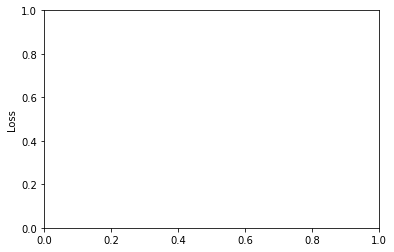

In [7]:
hist = model.fit(train_loader, epochs=epochs, validation_data=test_loader, callbacks=[cp_callback, early_stop])

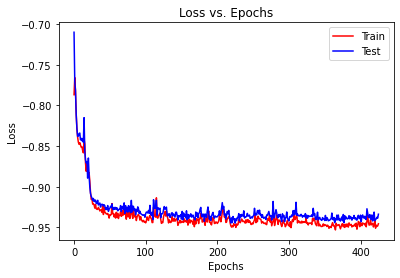

In [8]:
plt.plot(hist.history['loss'], color='red', label='Train')
plt.plot(hist.history['val_loss'], color='blue', label='Test')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(loc="upper right")
plt.title('Loss vs. Epochs')
plt.show()
# plt.savefig('loss_plot.png')hist = model.fit(train_loader, epochs=epochs, validation_data=test_loader, callbacks=[cp_callback, early_stop])


In [34]:
model.save_weights(checkpoint_path)

In [8]:
checkpoint_path = "./check_points/0627_cp.ckpt"
model.load_weights(checkpoint_path)

In [13]:
output = model.predict(sample_loader)
moved = output['moved']
deformation = output['deformation']

In [47]:
deformation.shape

(1, 64, 128, 128, 3)

In [55]:
gt_moved.shape

(128, 128, 64)

In [10]:
filename = "./chaos_train_voxel/gtaffine/1.nii.gz"

gt_moving = nib.load(filename).get_fdata()
gt_moving = gt_moving.swapaxes(0,2)
gt_moving = tf.expand_dims(gt_moving, axis=0)
gt_moving = tf.expand_dims(gt_moving, axis=4)
print(gt_moving.shape)

nb, nd, nh, nw, nc = tf.shape(deformation)

# Regular grid.
grid = regular_grid_3d(nd, nh, nw)

grid = tf.expand_dims(grid, axis=0) 
multiples = tf.stack([nb, 1, 1, 1, 1])
grid = tf.tile(grid, multiples)

print(deformation[0].shape)
grid_new = grid + deformation[0]
grid_new = tf.clip_by_value(grid_new, -1, 1)

gt_moving = tf.cast(gt_moving, tf.float32)

gt = grid_sample_3d(gt_moving, grid_new, name='gt')
print(gt.shape)
gt = gt[0].numpy()
gt = gt.squeeze()
print(gt.shape)
gt = gt.swapaxes(0,2)
x = nib.Nifti1Image(gt, None) 
nib.save(x,'./chaos_train_voxel/gtaffine.nii.gz')

(1, 64, 128, 128, 1)
(64, 128, 128, 3)
(19, 64, 128, 128, 1)
(64, 128, 128)


In [32]:
# Voxel Affine 저장 ###########
output = model.predict(sample_loader)
moved = output['moved']
moved = moved * max_value
a = 1
j = 0
for i in range (0, 29):
    filename = "./chaos_train_voxel/gt_resize/" + str(a) + ".nii.gz"
    if os.path.isfile(filename):
        
        x = moved[j]
        x = np.squeeze(x)
        x = x.swapaxes(0,2) 
        print(a, ":", x.shape )
        savename = "./chaos_train_voxel/6.최종결과/" + str(a) + ".nii.gz"
        x = nib.Nifti1Image(x, None) 
        nib.save(x,savename)
        
        j += 1
        
    a += 1

1 : (128, 128, 64)
2 : (128, 128, 64)
5 : (128, 128, 64)
6 : (128, 128, 64)
8 : (128, 128, 64)
10 : (128, 128, 64)
14 : (128, 128, 64)
16 : (128, 128, 64)
18 : (128, 128, 64)
19 : (128, 128, 64)
21 : (128, 128, 64)
22 : (128, 128, 64)
23 : (128, 128, 64)
24 : (128, 128, 64)
25 : (128, 128, 64)
26 : (128, 128, 64)
27 : (128, 128, 64)
28 : (128, 128, 64)
29 : (128, 128, 64)


In [10]:
result = model.evaluate(sample_loader)

1/1 [==============================] - 0s 956us/step - loss: -0.5884 - deformation_loss: 0.0041 - tf_op_layer_moved_loss: -0.5892


In [11]:
moved = moved * max_value
print(moved.shape)
a = moved[0]
b = deformation[0]

print(a.shape)
a = a.swapaxes(0,2) 
b = b.swapaxes(0,2) 
print(a.shape)

a = nib.Nifti1Image(a,None) 
b = nib.Nifti1Image(b,None)

nib.save(a,'chaos_train_voxel/moved_.nii.gz')
nib.save(b,'chaos_train_voxel/deformation_.nii.gz')

(19, 64, 128, 128, 1)
(64, 128, 128, 1)
(128, 128, 64, 1)


In [11]:
def dice_coef(y_true, y_pred_bin):
                    
    intersection = 2.0 * np.sum(y_true * y_pred_bin)
    union = (np.sum(y_true) + np.sum(y_pred_bin))
    return (intersection / union)

In [17]:
filename = "./chaos_train_voxel/gtaffine.nii.gz"

rgt = nib.load(filename).get_fdata()
rgt = rgt.swapaxes(0,2)

mov = np.squeeze(moved[0])

print(dice_coef(mov, rgt))

0.2385860440177458


In [21]:
gt_moved = gt_moved.swapaxes(0,2)

c = nib.Nifti1Image(gt_moved, None)
nib.save(c,'0530 결과/gt0530_04.nii.gz')

In [4]:
model.summary()

Model: "voxelmorph1"
__________________________________________________________________________________________________
Layer (type)                    Output Shape         Param #     Connected to                     
static (InputLayer)             [(None, 64, 128, 128 0                                            
__________________________________________________________________________________________________
moving (InputLayer)             [(None, 64, 128, 128 0                                            
__________________________________________________________________________________________________
concatenate (Concatenate)       (None, 64, 128, 128, 0           static[0][0]                     
                                                                 moving[0][0]                     
__________________________________________________________________________________________________
conv3d (Conv3D)                 (None, 32, 64, 64, 1 880         concatenate[0][0]      